# Анализ предобученных моделей / Pretrained Models Analysis

Ноутбук загружает результаты оценки **предобученных (foundation) моделей** распознавания эмоций в речи
на тестовом наборе данных **Dusha** (`dusha_resd_test.lmdb`, 6616 сэмплов) и визуализирует их метрики.

Модели не обучались нами: это открытые модели с Hugging Face, которые запускаются "как есть"
(zero-shot оценка) на нашем тестовом корпусе. Результаты предвычислены скриптами
`ruintona/my_experiments/checkpoints/pretrained/*_eval_*.py` (полный прогон по `dusha_resd_test`)
и сохранены в JSON (`checkpoints/pretrained/*_eval_*.json`).

Для каждой модели выводятся:
- Краткое описание и ссылка на источник
- Сводные метрики (Accuracy, Balanced Accuracy, UAR, F1, MCC, ROC-AUC, Top-2)
- Отчёт по классам (Precision / Recall / F1 / Support)
- Матрица ошибок (confusion matrix)

**Эмоции (4 класса):** `angry` · `sad` · `neutral` · `positive`

> Используются сторонние предобученные модели; их источники и лицензии — [SOURCES.md](../../../SOURCES.md).


---
## Содержание

| # | Модель | Описание | Источник |
|---|--------|----------|----------|
| 1 | [HuBERT-large](#1-hubert-large) | Self-supervised HuBERT-large, fine-tuned на **Dusha** | `xbgoose/hubert-speech-emotion-recognition-russian-dusha-finetuned` |
| 2 | [Whisper-large-v3](#2-whisper-large-v3) | OpenAI Whisper-large-v3, fine-tuned для SER | `firdhokk/speech-emotion-recognition-with-openai-whisper-large-v3` |
| 3 | [WavLM-BERT fusion](#3-wavlm-bert-fusion) | Мультимодальная WavLM + RuBERT, fine-tuned на **RESD** | `Aniemore/wavlm-bert-fusion-s-emotion-russian-resd` |


In [ ]:
get_ipython().run_line_magic('matplotlib', 'inline')

import sys
import json
from pathlib import Path

def _find_repo_root():
    cwd = Path.cwd().resolve()
    for p in [cwd] + list(cwd.parents):
        if (p / 'ruintona' / 'my_experiments').is_dir():
            return p
    return None

_REPO_ROOT = _find_repo_root()
if _REPO_ROOT is not None and str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

from ruintona.my_experiments.utils.config_utils import (
    PROJECT_ROOT, DATASET_PATH, TARGET_NAMES,
)

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

PRETRAINED_DIR = PROJECT_ROOT / 'my_experiments' / 'checkpoints' / 'pretrained'

EVAL_JSON_GLOBS = {
    'hubert':  'hubert_large_dusha_eval_*.json',
    'whisper': 'whisper_large_v3_eval_*.json',
    'wavlm':   'wavlm_bert_fusion_eval_*.json',
}

def find_eval_jsons():
    found = {}
    for key, glob in EVAL_JSON_GLOBS.items():
        matches = sorted(PRETRAINED_DIR.glob(glob))
        found[key] = max(matches, key=lambda p: p.stat().st_mtime) if matches else None
    return found

eval_jsons = find_eval_jsons()
TEST_LMDB = DATASET_PATH / 'processed_dataset_090' / 'aggregated_dataset' / 'dusha_resd_test.lmdb'

print(f'Каталог с результатами: {PRETRAINED_DIR}')
print(f'Тестовый корпус: {TEST_LMDB}  (существует: {TEST_LMDB.exists()})')
for key, path in eval_jsons.items():
    print(f'  {key:8}: {path.name if path else "НЕ НАЙДЕН"}')

---
## Вспомогательные функции

In [2]:
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns


def load_eval_result(path):
    if path is None or not Path(path).exists():
        raise FileNotFoundError(f'JSON с результатами не найден: {path}')
    with open(path, encoding='utf-8') as f:
        return json.load(f)


def per_class_from_confusion(cm, target_names):
    cm = np.asarray(cm, dtype=float)
    rows = []
    for i, name in enumerate(target_names):
        tp = cm[i, i]
        support = cm[i, :].sum()
        pred = cm[:, i].sum()
        recall = tp / support if support > 0 else 0.0
        precision = tp / pred if pred > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        rows.append({
            'Class': name,
            'Precision': f'{precision:.4f}',
            'Recall': f'{recall:.4f}',
            'F1-Score': f'{f1:.4f}',
            'Support': int(support),
        })
    return pd.DataFrame(rows)


def plot_confusion_matrix(cm, target_names):
    cm = np.asarray(cm, dtype=int)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, data, fmt, title_text, cmap in [
        (axes[0], cm, 'd', 'Counts', 'Blues'),
        (axes[1], cm_norm, '.2f', 'Normalized (by true class)', 'Blues'),
    ]:
        sns.heatmap(
            data, annot=True, fmt=fmt, cmap=cmap,
            xticklabels=target_names, yticklabels=target_names,
            ax=ax, linewidths=0.5, linecolor='white',
            vmin=0, vmax=(1.0 if fmt == '.2f' else None),
        )
        ax.set_xlabel('Predicted', fontsize=11)
        ax.set_ylabel('True', fontsize=11)
        ax.set_title(title_text, fontsize=12)
    plt.suptitle('Confusion Matrix', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


def overview_df(metrics):
    nice_names = {
        'accuracy': 'Accuracy',
        'balanced_accuracy': 'Balanced Accuracy',
        'uar': 'UAR (macro recall)',
        'precision_macro': 'Precision (macro)',
        'recall_macro': 'Recall (macro)',
        'f1_macro': 'F1 (macro)',
        'f1_weighted': 'F1 (weighted)',
        'mcc': 'MCC',
        'top2_accuracy': 'Top-2 Accuracy',
        'roc_auc_ovr_macro': 'ROC-AUC (OvR macro)',
        'loss': 'Loss',
    }
    rows = []
    for k, v in metrics.items():
        name = nice_names.get(k, k.replace('_', ' ').title())
        if isinstance(v, float) and np.isnan(v):
            val = 'N/A'
        elif isinstance(v, float):
            val = f'{v:.4f}'
        elif isinstance(v, (int, np.integer)):
            val = f'{float(v):.4f}'
        else:
            val = str(v)
        rows.append({'Metric': name, 'Value': val})
    return pd.DataFrame(rows)


def show_eval_result(result, title):
    metrics = result['metrics']
    cm = np.asarray(result['confusion_matrix'])
    label_names = result.get('label_names', TARGET_NAMES)
    samples_used = result.get('samples_used', int(cm.sum()))

    print(f'{"" * 70}')
    print(f'  {title}')
    print(f'{"" * 70}')
    print(f'\nТестовый корпус: dusha_resd_test (n = {samples_used})')
    print(f'Модель: {result.get("model_name")}')
    if result.get('feature_extractor_name'):
        print(f'Feature extractor: {result["feature_extractor_name"]}')
    print(f'Device: {result.get("device")} | Дата прогона: {result.get("saved_at")}')

    print('\nOverall Metrics:')
    display(overview_df(metrics))

    print('Per-Class Report:')
    display(per_class_from_confusion(cm, label_names))

    plot_confusion_matrix(cm, label_names)

---
## 1. HuBERT-large

**HuBERT-large (SER, русский)** — дообучение self-supervised модели
`facebook/hubert-large-ls960-ft`
(HuBERT-large, ~316M параметров, обучена маскированным предсказанием скрытых единиц на 960h LibriSpeech)
на корпусе **Dusha** (датасет проекта Salute Developers/Golos,
[структура](https://github.com/salute-developers/golos/tree/master/dusha#dataset-structure)).

- **Обучена на:** Dusha (половина train-выборки), 2 эпохи, batch 8, lr 5e-5, A100
- **Нативные метки (5):** `neutral`, `angry`, `positive`, `sad`, `other`
- **Отчёт автора (test):** accuracy 0.86, balanced 0.76, macro-F1 0.81
- **Лицензия:** apache-2.0
- **Источник:** `xbgoose/hubert-speech-emotion-recognition-russian-dusha-finetuned` — см. [SOURCES.md](../../../SOURCES.md)

В нашей оценке выход модели (5 классов, включая `other`) маппится на 4 целевых класса
(`angry` · `sad` · `neutral` · `positive`).


  HuBERT-large (fine-tuned на Dusha)


Тестовый корпус: dusha_resd_test (n = 6616)
Модель: xbgoose/hubert-speech-emotion-recognition-russian-dusha-finetuned
Feature extractor: facebook/hubert-large-ls960-ft
Device: cuda | Дата прогона: 2026-05-23T16:50:03

Overall Metrics:


,Metric,Value
0,Loss,0.5708
1,Accuracy,0.8052
2,Wa,0.8052
3,Balanced Accuracy,0.8127
4,UAR (macro recall),0.8127
5,Precision (macro),0.8455
6,Recall (macro),0.8127
7,F1 (macro),0.8150
8,F1 (weighted),0.8111
9,MCC,0.7510


Per-Class Report:


,Class,Precision,Recall,F1-Score,Support
0,angry,0.9077,0.8353,0.8700,1378
1,sad,0.9756,0.7049,0.8185,2213
2,neutral,0.6146,0.9208,0.7372,1730
3,positive,0.8842,0.7900,0.8344,1295


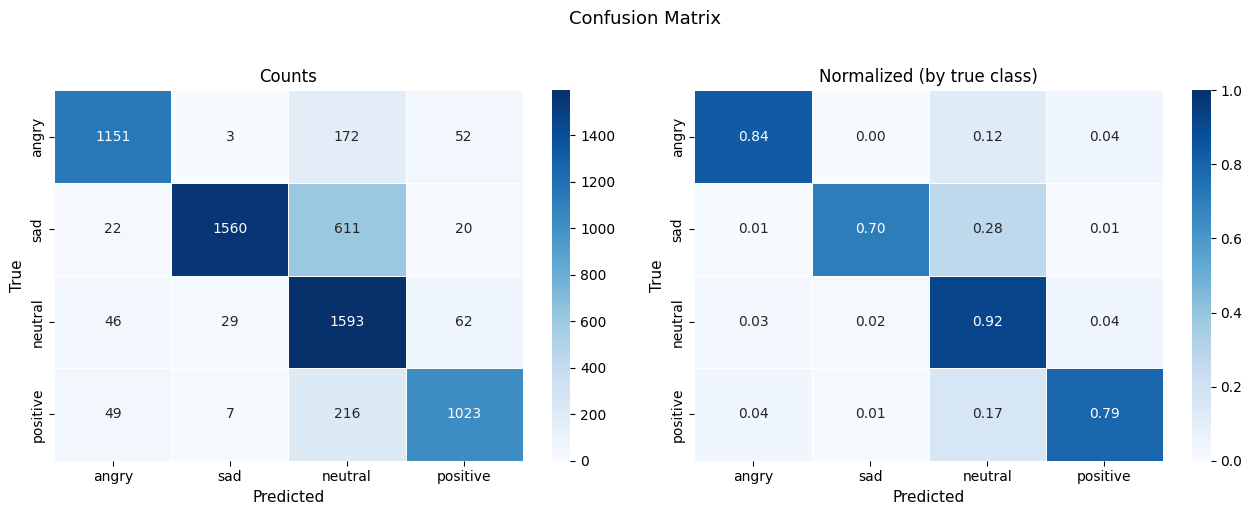

In [3]:
path = eval_jsons['hubert']
if path is None:
    print('JSON с результатами HuBERT не найден — раздел пропущен.')
else:
    show_eval_result(load_eval_result(path), 'HuBERT-large (fine-tuned на Dusha)')

---
## 2. Whisper-large-v3

**Whisper-large-v3 (SER)** — fine-tune открытой модели
`openai/whisper-large-v3`
(~1.55B параметров, обучена на 680k+ часов многоязычной речи) на задачу классификации эмоций.

- **Обучена на:** актёрских англоязычных датасетах **RAVDESS, SAVEE, TESS, URDU**
  (класс `calm` исключён из-за малочисленности), 25 эпох, lr 5e-5
- **Нативные метки (7):** `angry`, `disgust`, `fearful`, `happy`, `neutral`, `sad`, `surprised`
- **Отчёт автора (test):** accuracy 0.92, F1 0.92
- **Лицензия:** apache-2.0 (fine-tune; базовая `openai/whisper-large-v3` — MIT)
- **Источник:** `firdhokk/speech-emotion-recognition-with-openai-whisper-large-v3` — см. [SOURCES.md](../../../SOURCES.md)

Наши 4 класса получаются маппингом нативных меток (`angry`→angry, `sad`→sad, `neutral`→neutral,
`happy`→positive; `disgust`/`fearful`/`surprised` не используются).


  Whisper-large-v3 (SER)


Тестовый корпус: dusha_resd_test (n = 6616)
Модель: firdhokk/speech-emotion-recognition-with-openai-whisper-large-v3
Device: cuda | Дата прогона: 2026-05-20T01:09:20

Overall Metrics:


,Metric,Value
0,Loss,2.7848
1,Accuracy,0.4349
2,Wa,0.4349
3,Balanced Accuracy,0.3777
4,UAR (macro recall),0.3777
5,Precision (macro),0.5427
6,Recall (macro),0.3777
7,F1 (macro),0.3448
8,F1 (weighted),0.3651
9,MCC,0.2310


Per-Class Report:


,Class,Precision,Recall,F1-Score,Support
0,angry,0.7899,0.0791,0.1438,1378
1,sad,0.4098,0.9191,0.5669,2213
2,neutral,0.3652,0.1613,0.2237,1730
3,positive,0.6059,0.3514,0.4448,1295


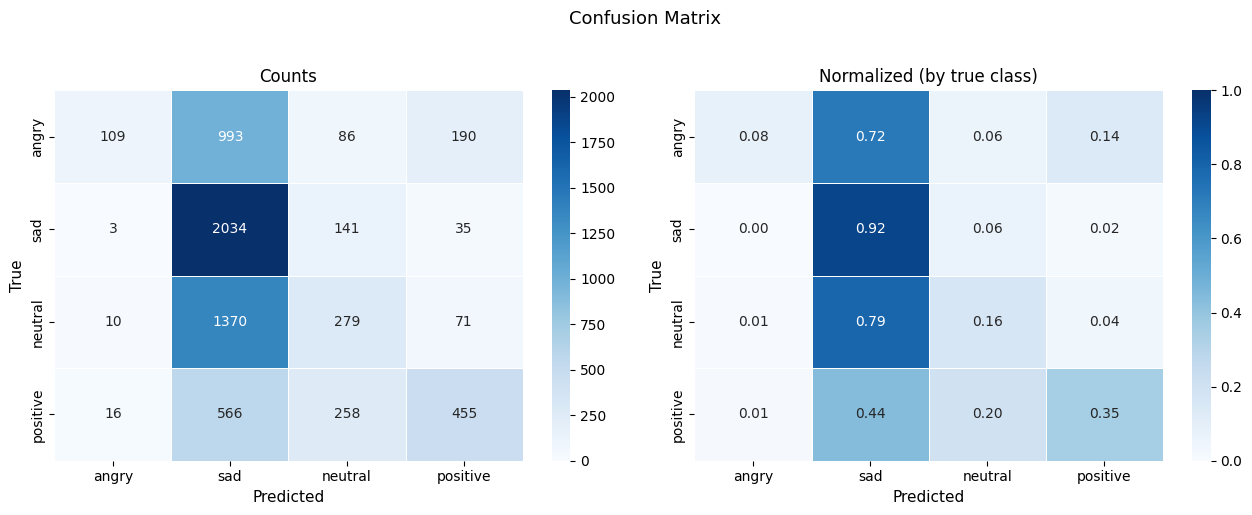

In [4]:
path = eval_jsons['whisper']
if path is None:
    print('JSON с результатами Whisper не найден — раздел пропущен.')
else:
    show_eval_result(load_eval_result(path), 'Whisper-large-v3 (SER)')

---
## 3. WavLM-BERT fusion

**WavLM-BERT fusion (мультимодальная, русский)** — модель проекта
[Aniemore](https://github.com/Aniemore/Aniemore): аудио-башня WavLM/wav2vec2, дообученная для русского ASR
(`jonatasgrosman/exp_w2v2t_ru_wavlm_s363`, см. [SOURCES.md](../../../SOURCES.md)),
текстовый энкодер `DeepPavlov/rubert-base-cased`,
объединённые fusion-классификатором. Вход — waveform 16 кГц + транскрипция реплики (~504M параметров).

- **Обучена на:** **RESD** (Russian Emotional Speech Dataset, Aniemore)
- **Нативные метки (7):** `anger`, `disgust`, `enthusiasm`, `fear`, `happiness`, `neutral`, `sadness`
- **Отчёт автора:** RESD test macro-F1 0.794; на Dusha podcast test — UA 0.35 / WA 0.07 / F1 0.092
  (в карточке авторы честно отмечают деградацию на спонтанной речи)
- **Лицензия:** MIT
- **Источник:** `Aniemore/wavlm-bert-fusion-s-emotion-russian-resd` — см. [SOURCES.md](../../../SOURCES.md)

В нашей оценке выход маппится на 4 целевых класса
(`anger`→angry, `sadness`→sad, `neutral`→neutral, `happiness`→positive; остальные не используются).


  WavLM-BERT fusion (RESD)


Тестовый корпус: dusha_resd_test (n = 6616)
Модель: Aniemore/wavlm-bert-fusion-s-emotion-russian-resd
Device: cuda | Дата прогона: 2026-05-19T15:36:02

Overall Metrics:


,Metric,Value
0,Loss,1.8693
1,Accuracy,0.5521
2,Wa,0.5521
3,Balanced Accuracy,0.5229
4,UAR (macro recall),0.5229
5,Precision (macro),0.5674
6,Recall (macro),0.5229
7,F1 (macro),0.5034
8,F1 (weighted),0.5262
9,MCC,0.4036


Per-Class Report:


,Class,Precision,Recall,F1-Score,Support
0,angry,0.6767,0.2765,0.3926,1378
1,sad,0.6320,0.8577,0.7278,2213
2,neutral,0.5603,0.3087,0.3981,1730
3,positive,0.4006,0.6486,0.4953,1295


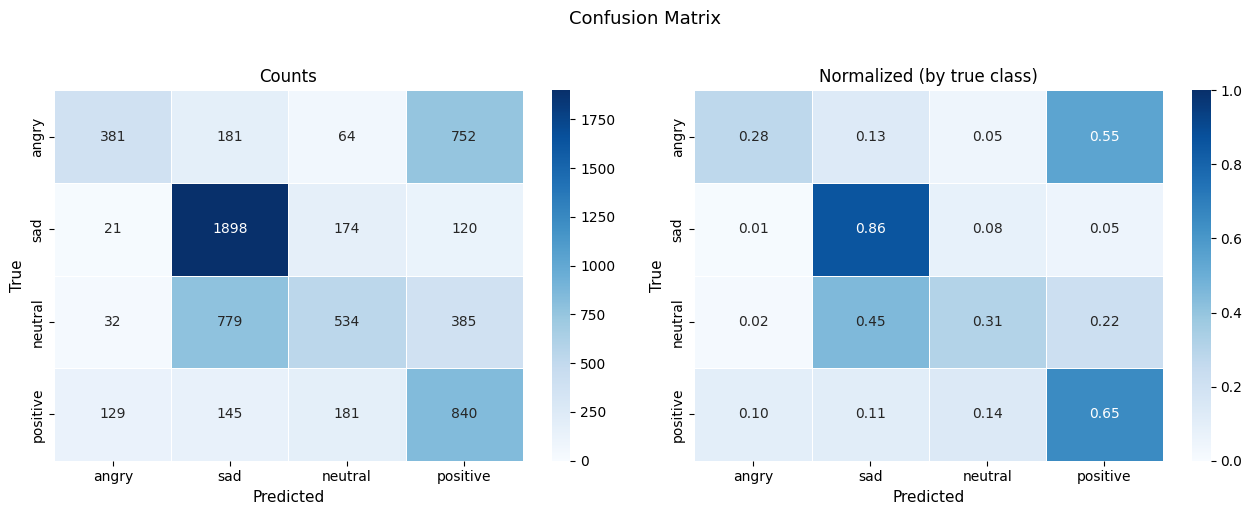

In [5]:
path = eval_jsons['wavlm']
if path is None:
    print('JSON с результатами WavLM-BERT fusion не найден — раздел пропущен.')
else:
    show_eval_result(load_eval_result(path), 'WavLM-BERT fusion (RESD)')

---
## Сравнение моделей

,Accuracy,Balanced Acc,UAR,F1 (macro),F1 (weighted),MCC,Top-2 Acc,ROC-AUC
Model,,,,,,,,
HuBERT-large,0.8052,0.8127,0.8127,0.8150,0.8111,0.7510,0.9589,0.9708
Whisper-large-v3,0.4349,0.3777,0.3777,0.3448,0.3651,0.2310,0.7344,0.7188
WavLM-BERT fusion,0.5521,0.5229,0.5229,0.5034,0.5262,0.4036,0.8040,0.7782


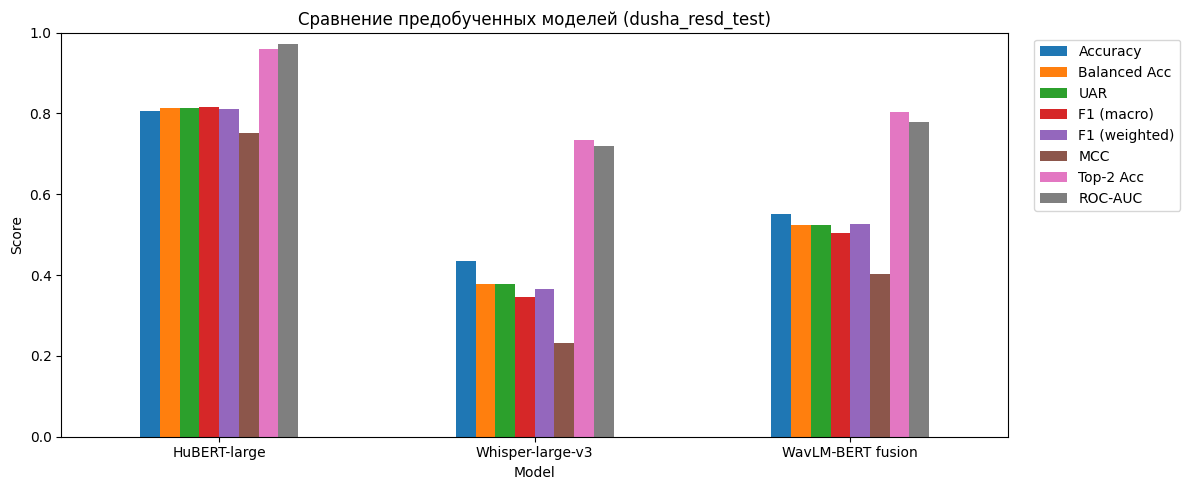

In [6]:
rows = []
for key, title in [('hubert', 'HuBERT-large'), ('whisper', 'Whisper-large-v3'), ('wavlm', 'WavLM-BERT fusion')]:
    path = eval_jsons[key]
    if path is None:
        continue
    m = load_eval_result(path)['metrics']
    rows.append({
        'Model': title,
        'Accuracy': m['accuracy'],
        'Balanced Acc': m['balanced_accuracy'],
        'UAR': m['uar'],
        'F1 (macro)': m['f1_macro'],
        'F1 (weighted)': m['f1_weighted'],
        'MCC': m['mcc'],
        'Top-2 Acc': m['top2_accuracy'],
        'ROC-AUC': m['roc_auc_ovr_macro'],
    })

cmp_df = pd.DataFrame(rows).set_index('Model')
display(cmp_df.style.format('{:.4f}').highlight_max(axis=0, color='#a5d6a7'))

ax = cmp_df.plot(kind='bar', figsize=(12, 5), rot=0, title='Сравнение предобученных моделей (dusha_resd_test)')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
## Выводы

- **HuBERT-large (fine-tuned на Dusha)** существенно обгоняет остальные модели на нашем тестовом корпусе
  (accuracy ~0.81, F1-macro ~0.82). Это ожидаемо: модель дообучалась на том же корпусе Dusha.
- **WavLM-BERT fusion (RESD)** и **Whisper-large-v3 (SER)** заметно хуже (accuracy ~0.55 и ~0.43):
  они обучены на других корпусах (актёрская/лабораторная речь: русский RESD и английские RAVDESS/SAVEE/TESS/URDU)
  и деградируют на спонтанной русской речи Dusha.
- Это подтверждает важность обучения/дообучения на целевом корпусе: "из коробки" general-purpose
  предобученные модели не решают задачу SER на Dusha.

_Результаты получены скриптами `checkpoints/pretrained/*_eval_*.py` на `dusha_resd_test.lmdb` (6616 сэмплов)
и загружены из сохранённых JSON-отчётов._